# CellChat downstream — signaling to CD4 T cells by TLS radial category (R)

Visualize the CellChat results from [`01_cellchat_R_tls-category.ipynb`](01_cellchat_R_tls-category.ipynb),
focusing on signaling **to** activated CD4 T cells split by TLS radial position (core / outer / surround).
Includes custom adaptations of several CellChat plotting functions that restrict the heatmaps to these
receiver groups, plus standard CellChat role/circle plots.

**Pinned Environment:** [`conda_envs/cellchat.yml`](../../conda_envs/cellchat.yml)

In [1]:
#remotes::install_github("jinworks/CellChat@88c2e13")

suppressPackageStartupMessages({
    library(CellChat)
    library(zellkonverter)
    library(SingleCellExperiment)
    library(ComplexHeatmap)
})



In [2]:
library(tidyr)
library(tibble)


Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand


The following object is masked from ‘package:igraph’:

    crossing



Attaching package: ‘tibble’


The following object is masked from ‘package:igraph’:

    as_data_frame




In [7]:
source(file.path(dirname(dirname(getwd())), "config", "paths.R"))

out_dir <- file.path(BASE_OUTDIR, "downstream_analysis")
out_dir_cellchat <- file.path(out_dir, "cellchat_tls-category")
plot_out_dir <- file.path(out_dir_cellchat, "plots")

## Load cellchat results

In [8]:
path =  file.path(out_dir_cellchat, "cellchat_HDM_day3_trim_0.1_intrange_50_contact_10_popsize_FALSE.rds")
cellchat = readRDS(path)


## Plotting palettes


In [9]:
celltype_palette_mapped <- c('AT1'= '#ffff00',
 'AT2'= '#1ce6ff',
 'Club'= '#ff34ff',
 'Ciliated'= '#ff4a46',
 'SMC'= '#008941',
 'Col13a1+ fibroblast'= '#006fa6',
 'Col14a1+ fibroblast'= '#a30059',
 'Myofibroblast'= '#ffdbe5',
 'Pericyte 1'= '#7a4900',
 'Pericyte 2'= '#0000a6',
 'Mesothelial'= '#63ffac',
 'Cap'= '#b79762',
 'Cap-a'= '#004d43',
 'Art'= '#8fb0ff',
 'Vein'= '#997d87',
 'Lymph'= '#5a0007',
 'Mono'= '#809693',
 'Int Mf'= '#6a3a4c',
 'Alv Mf'= '#1b4400',
 'Neut'= '#4fc601',
 'cDC1'= '#3b5dff',
 'Ccr7- cDC2'= '#4a3b53',
 'Ccr7+ cDC2'= '#ff2f80',
 'B cell'= '#61615a',
 'Plasmablast'= '#ba0900',
 'NK cell'= '#6b7900',
 'gd T cell'= '#00c2a0',
 'ILC2'= '#ffaa92',
 'CD8 naive'= '#ff90c9',
 'CD8 act'= '#b903aa',
 'CD4 naive'= '#d16100',
 'CD4 act (tls core)'='#006400', 
                             'CD4 act (tls outer)'='#98FB98', 
                             'CD4 act (tls surround)'='#BDB76B'                             
)

## Adjust cell label order for plotting

In [10]:
# First adjust the cell label order
label_df <- read.csv(file.path(INPUTS_DIR, "20250519_mouse_lung_label_mapping_ordered.csv"))

# Get the current labels in the CellChat object
cellchat_labels <- unique(cellchat@idents)

# Keep only labels that are in the cellchat object
ordered_labels <- label_df$label_fine[label_df$label_fine %in% cellchat_labels]

# Optional: Append custom labels (if needed)
extra_labels <- c('CD4 act (tls surround)','CD4 act (tls outer)', 'CD4 act (tls core)')
cell_order <- c(as.character(ordered_labels), extra_labels)
cell_order <- rev(cell_order)

# Update the CellChat object with new label order
cellchat@meta$labels <- factor(cellchat@idents, levels = cell_order)
cellchat <- updateClusterLabels(cellchat, new.order = cell_order)

Only reorder cell groups but do not rename cell groups!

Reorder cell groups! 



The cell group order before reordering is  AT1 AT2 Alv Mf Art B cell CD4 act (tls core) CD4 act (tls outer) CD4 act (tls surround) CD4 naive CD8 act CD8 naive Cap Cap-a Ccr7+ cDC2 Ccr7- cDC2 Ciliated Club Col13a1+ fibroblast Col14a1+ fibroblast ILC2 Int Mf Lymph Mesothelial Mono Myofibroblast NK cell Neut Pericyte 1 Pericyte 2 Plasmablast SMC Vein cDC1 gd T cell 
The cell group order after reordering is  CD4 act (tls core) CD4 act (tls outer) CD4 act (tls surround) CD4 naive CD8 act CD8 naive ILC2 gd T cell NK cell Plasmablast B cell Ccr7+ cDC2 Ccr7- cDC2 cDC1 Neut Alv Mf Int Mf Mono Lymph Vein Art Cap-a Cap Mesothelial Pericyte 2 Pericyte 1 Myofibroblast Col14a1+ fibroblast Col13a1+ fibroblast SMC Ciliated Club AT2 AT1 


We now re-run computeCommunProbPathway`,`aggregateNet`, and `netAnalysis_computeCentrality`...



In [11]:
# reorder palette
celltype_palette_mapped <- celltype_palette_mapped[cell_order]
celltype_palette_mapped

CD4 act (tls core)    CD4 act (tls outer) CD4 act (tls surround) 
             "#006400"              "#98FB98"              "#BDB76B" 
             CD4 naive                CD8 act              CD8 naive 
             "#d16100"              "#b903aa"              "#ff90c9" 
                  ILC2              gd T cell                NK cell 
             "#ffaa92"              "#00c2a0"              "#6b7900" 
           Plasmablast                 B cell             Ccr7+ cDC2 
             "#ba0900"              "#61615a"              "#ff2f80" 
            Ccr7- cDC2                   cDC1                   Neut 
             "#4a3b53"              "#3b5dff"              "#4fc601" 
                Alv Mf                 Int Mf                   Mono 
             "#1b4400"              "#6a3a4c"              "#809693" 
                 Lymph                   Vein                    Art 
             "#5a0007"              "#997d87"              "#8fb0ff" 
                 Cap-a                    Cap            Mesothelial 
             "#004d43"              "#b79762"              "#63ffac" 
            Pericyte 2             Pericyte 1          Myofibroblast 
             "#0000a6"              "#7a4900"              "#ffdbe5" 
   Col14a1+ fibroblast    Col13a1+ fibroblast                    SMC 
             "#a30059"              "#006fa6"              "#008941" 
              Ciliated                   Club                    AT2 
             "#ff4a46"              "#ff34ff"              "#1ce6ff" 
                   AT1 
             "#ffff00"

### Run netAnalysis_computeCentrality

In [13]:
cellchat <- netAnalysis_computeCentrality(cellchat, slot.name = "netP")

### Custom: incoming-signaling heatmap restricted to CD4 TLS categories

Inline adaptation of CellChat's `netAnalysis_signalingRole_heatmap`
([source](https://github.com/jinworks/CellChat/blob/main/R/analysis.R)) — builds the incoming-signaling
strength heatmap (pathways × cell groups) but restricts the displayed **receiver** columns to the
activated-CD4 TLS categories. Customizations:
- each pathway is scaled across **all** cell types first, then the matrix is subset to `targets.use`
  (so relative strengths stay comparable);
- pathways with no signal to the targets are dropped;
- the retained pathways (rows) are clustered (ward.D2).

In [36]:
#  customizing: netAnalysis_signalingRole_heatmap 

pattern <- "incoming"
slot.name = "netP"
# color.heatmap = "BuGn"
color.heatmap = "Blues"
# color.heatmap = rev("Spectral")
signaling=NULL
title = NULL
color.use = NULL
width = 2
height = 12
font.size = 8
font.size.title = 10
cluster.rows = FALSE
cluster.cols = FALSE

# ka add
targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)')

object = cellchat
centr <- slot(object, slot.name)$centr
outgoing <- matrix(0, nrow = nlevels(object@idents), ncol = length(centr))
incoming <- matrix(0, nrow = nlevels(object@idents), ncol = length(centr))
dimnames(outgoing) <- list(levels(object@idents), names(centr))
dimnames(incoming) <- dimnames(outgoing)

# length of centr is equivalent to the number of signaling pathways 
for (i in 1:length(centr)) {
    outgoing[,i] <- centr[[i]]$outdeg
    incoming[,i] <- centr[[i]]$indeg
  }
# mat is transpose of incoming or outgoing, such that rows are signal pathways, and columns are cell types
  if (pattern == "outgoing") {
    mat <- t(outgoing)
    legend.name <- "Outgoing"
  } else if (pattern == "incoming") {
    mat <- t(incoming)
    legend.name <- "Incoming"
  } else if (pattern == "all") {
    mat <- t(outgoing+ incoming)
    legend.name <- "Overall"
  }
  if (is.null(title)) {
    title <- paste0(legend.name, " signaling patterns")
  } else {
    title <- paste0(paste0(legend.name, " signaling patterns"), " - ",title)
  }

# drop signaling pathway rows not in specified list, if specified 
  if (!is.null(signaling)) {
    mat1 <- mat[rownames(mat) %in% signaling, , drop = FALSE]
    mat <- matrix(0, nrow = length(signaling), ncol = ncol(mat))
    idx <- match(rownames(mat1), signaling)
    mat[idx[!is.na(idx)], ] <- mat1
    dimnames(mat) <- list(signaling, colnames(mat1))
  }

# row scale the matrix; rows are signals, so this scales a given signal across all cell types 
  mat.ori <- mat
  mat <- sweep(mat, 1L, apply(mat, 1, max), '/', check.margin = FALSE) # column scaling instead would be: mat <- sweep(mat, 2L, apply(mat, 2, max), '/', check.margin = FALSE)
  mat[mat == 0] <- NA

# KA add: drop receiver cell types not in targets.use -- AFTER scaling across pathways
if (!is.null(targets.use)) {
  mat1 <- mat[, colnames(mat) %in% targets.use, drop = FALSE]
  mat <- matrix(0, nrow = nrow(mat), ncol = length(targets.use))
  idx <- match(colnames(mat1), targets.use)
  mat[, idx[!is.na(idx)]] <- mat1
  dimnames(mat) <- list(rownames(mat1), targets.use)
}

 # KA add: remove signaling pathways that are entirely NA
    keep <- !apply(mat, 1, function(x) all(is.na(x)))
    mat <- mat[keep, , drop = FALSE]
    # also drop these in the unscaled matrix
    mat.ori <- mat.ori[keep, , drop = FALSE]

if (is.null(color.use)) {
    color.use <- scPalette(length(colnames(mat)))
  }
  color.heatmap.use = grDevices::colorRampPalette((RColorBrewer::brewer.pal(n = 9, name = color.heatmap)))(100)

  df<- data.frame(group = colnames(mat)); rownames(df) <- colnames(mat)
  names(color.use) <- colnames(mat)

  if (min(mat, na.rm = T) == max(mat, na.rm = T)) {
    legend.break <- max(mat, na.rm = T)
  } else {
    legend.break <- c(round(min(mat, na.rm = T), digits = 1), round(max(mat, na.rm = T), digits = 1))
  }

    # KA add: cluster columns
    mat.clust <- mat
    mat.clust[!is.finite(mat.clust)] <- 0   # replaces NA, NaN, Inf, -Inf
    cluster_rows = hclust(dist(mat.clust, method = "euclidean"), method = "ward.D2")
                   
  ht1 = Heatmap(mat, col = color.heatmap.use, na_col = "white", name = "Relative strength",
                cluster_rows = cluster_rows,
                cluster_columns = cluster.rows,
                column_names_side = "top",
                show_column_dend = FALSE,
                show_row_dend = FALSE,
                row_names_side = "left",row_names_rot = 0,row_names_gp = gpar(fontsize = font.size),column_names_gp = gpar(fontsize = font.size),
                width = unit(width, "cm"), height = unit(height, "cm"),
                column_title = title,column_title_gp = gpar(fontsize = font.size.title),column_names_rot = 90,
                heatmap_legend_param = list(title_gp = gpar(fontsize = 8, fontface = "plain"),title_position = "leftcenter-rot",
                                            border = NA, at = legend.break,
                                            legend_height = unit(20, "mm"),labels_gp = gpar(fontsize = 8),grid_width = unit(2, "mm"))
  )
  #  draw(ht1)

png 
  2

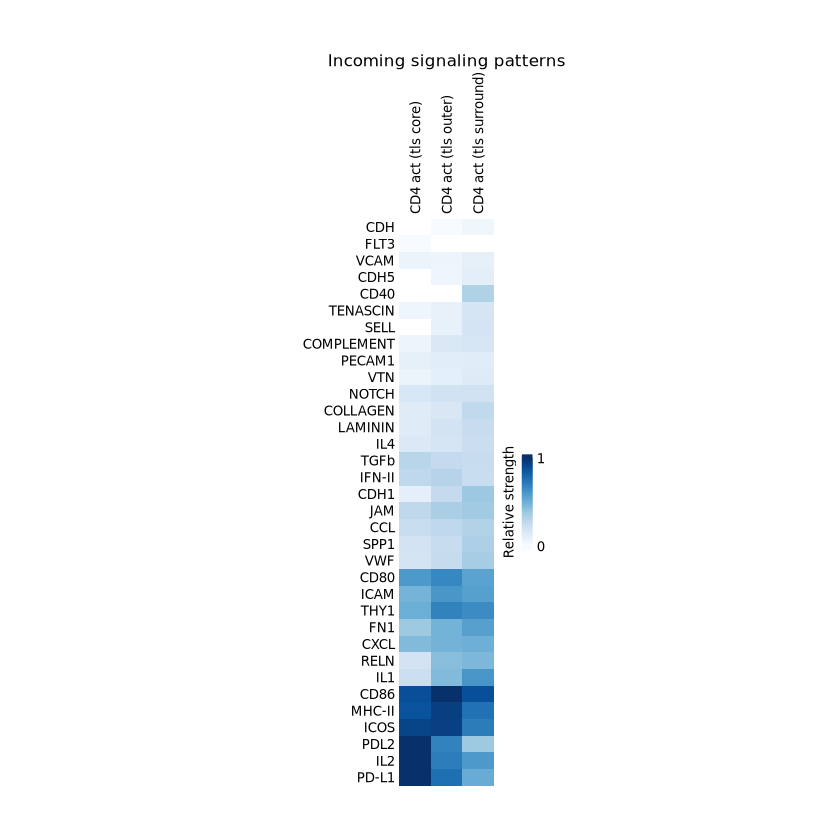

In [38]:
p <- draw(ht1)
pdf(file = file.path(plot_out_dir, "signaling_role_CD4_categories_vertical_scaled-on-all-receivers_clusterrows.pdf"))
p
dev.off()

### Custom function: `netVisual_heatmap_targetsOnly`

A function adapting CellChat's `netVisual_heatmap` to show communication probability from sender cell types
(rows) to only selected **target** cell groups (columns), for given signaling pathways or L–R pairs.

In [23]:
library(ComplexHeatmap)
library(RColorBrewer)
library(circlize)

netVisual_heatmap_targetsOnly <- function(object,
                                          sources.use = NULL,
                                          targets.use = NULL,
                                          signaling = NULL,
                                          pairLR.use = NULL,
                                          thresh = 0.05,
                                          # color.heatmap = "Spectral",
                                          color.heatmap = "BuGn",
                                          n.colors = 10,
                                          # direction = -1,
                                          direction = 1,
                                          font.size = 16,
                                          font.size.title = 10,
                                          title.name = NULL,
                                          cluster.rows = FALSE,
                                          cluster.cols = FALSE,
                                          row.order = NULL,
                                          return.data = FALSE) {
    # Heatmap of communication probability from senders -> selected target cell groups.
    #
    # Adapts CellChat's netVisual_heatmap to restrict the columns to `targets.use`. Pulls
    # significant interactions via subsetCommunication (by `signaling` or `pairLR.use`), keeps
    # only the requested targets, transforms probabilities (-1/log(prob)), and draws a
    # senders (rows) x targets (cols) ComplexHeatmap.
    #
    # Args:
    #   object        : a CellChat object.
    #   sources.use   : sender cell groups to include (NULL = all).
    #   targets.use   : receiver cell groups to show as columns.
    #   signaling     : signaling pathway(s) to subset to (or use pairLR.use).
    #   pairLR.use    : specific L-R pair(s) as a data.frame (overrides signaling).
    #   thresh        : p-value threshold for significant interactions (default 0.05).
    #   color.heatmap : RColorBrewer palette name (default 'BuGn').
    #   direction, n.colors, font.size, font.size.title, title.name : appearance options.
    #   cluster.rows, cluster.cols : whether to cluster rows/cols (default FALSE).
    #   row.order     : optional explicit row (sender) ordering.
    #   return.data   : if TRUE return the matrix, else the Heatmap object.
    # Returns:
    #   A ComplexHeatmap object (or matrix if return.data = TRUE); also draws it.


    # color setup
  color.heatmap = grDevices::colorRampPalette((RColorBrewer::brewer.pal(n = 9, name = color.heatmap)))(100)
    
  #--- get communication data
    if (is.null(pairLR.use)) {
        df.net <- subsetCommunication(object,
                                slot.name = "net",
                                sources.use = sources.use,
                                targets.use = targets.use,
                                signaling = signaling,
                                thresh = thresh)} 
    else{
        df.net <- subsetCommunication(object,
                        slot.name = "net",
                        sources.use = sources.use,
                        targets.use = targets.use,
                        pairLR.use = pairLR.use,
                        thresh = thresh)}      
    

  df.net.original <- df.net

  #--- filter to only selected targets
  df.net <- df.net[df.net$target %in% targets.use, , drop = FALSE]

  #--- drop nonsignificant
  df.net <- df.net[df.net$pval <= thresh, , drop = FALSE]

  if (nrow(df.net) == 0) stop("No significant interactions found for given targets")

  #--- row labels = sender + interaction
  df.net$row_label <- paste(df.net$source)

  #--- keep prob + pval for plotting
  df.net$prob[df.net$prob == 0] <- NA
  df.net$prob.original <- df.net$prob
  df.net$prob <- -1 / log(df.net$prob)

  #--- pivot into wide matrix
  mat <- reshape2::acast(df.net, row_label ~ target, value.var = "prob", fun.aggregate = mean)

  #--- color scale setup
  if (length(color.heatmap) == 1) {
    color.use <- tryCatch({
      RColorBrewer::brewer.pal(n = n.colors, name = color.heatmap)
    }, error = function(e) {
      scales::viridis_pal(option = color.heatmap, direction = -1)(n.colors)
    })
  } else {
    color.use <- color.heatmap
  }
  if (direction == -1) {
    color.use <- rev(color.use)
  }
  color.heatmap.use <- colorRampPalette(color.use)(100)

#--- enforce row order if provided
  if (!is.null(row.order)) {
    row.keep <- intersect(row.order, rownames(mat))
    mat <- mat[row.keep, , drop = FALSE]
  }

  #--- build heatmap
  ht <- Heatmap(mat,
                col = color.heatmap.use,
                na_col = "white",
                name = "Commun. Prob.",
                cluster_rows = cluster.rows, 
                show_row_dend = FALSE,
                cluster_columns=FALSE,
                row_names_gp = grid::gpar(fontsize = font.size),
                column_names_gp = grid::gpar(fontsize = font.size),
                column_title = title.name,
                column_title_gp = grid::gpar(fontsize = font.size.title),
                row_names_side = "left")

  draw(ht)

  if (return.data) {
    return(mat)
  } else {
    return(ht)
  }
}


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))



Attaching package: ‘circlize’


The following object is masked from ‘package:igraph’:

    degree




In [25]:
library(grid)
pairLR.use <- extractEnrichedLR(cellchat, signaling = c("PDL2"))
for (i in 1:nrow(pairLR.use)) {
  pairLR.use.single <- pairLR.use[i, , drop = FALSE]   # keep it as a data.frame
  print(pairLR.use.single)
    grid.newpage()        # <- clear the page for each new plot
    pdf(file = file.path(plot_out_dir, paste0(pairLR.use.single$interaction_name, "_senders_CD4_categories.pdf")), width=4, height=5)
    netVisual_heatmap_targetsOnly(cellchat, 
                                  color.heatmap = "Blues",
                                  direction = 1,
                                          # sources.use = c('B cell', 'Ccr7+ cDC2', 'Ccr7- cDC2', 'Alv Mf', 'Int Mf'),
                                          targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                                  pairLR.use = pairLR.use.single,
                                  # cluster.rows = TRUE, 
                                  return.data=FALSE)
    dev.off()

      # draw(ht)              # <- actually render it
    }


  interaction_name
1   PDCD1LG2_PDCD1


In [26]:
library(grid)
pairLR.use <- extractEnrichedLR(cellchat, signaling = c("MHC-II"))
for (i in 1:nrow(pairLR.use)) {
  pairLR.use.single <- pairLR.use[i, , drop = FALSE]   # keep it as a data.frame
  print(pairLR.use.single)
    grid.newpage()        # <- clear the page for each new plot
    pdf(file = file.path(plot_out_dir, paste0(pairLR.use.single$interaction_name, "_senders_CD4_categories.pdf")), width=4, height=7)
    netVisual_heatmap_targetsOnly(cellchat, 
                                  color.heatmap = "Blues",
                                  direction = 1,
                                          # sources.use = c('B cell', 'Ccr7+ cDC2', 'Ccr7- cDC2', 'Alv Mf', 'Int Mf'),
                                          targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                                  pairLR.use = pairLR.use.single,
                                  # cluster.rows = TRUE, 
                                  return.data=FALSE)
    dev.off()

      # draw(ht)              # <- actually render it
    }


  interaction_name
1       H2-AB1_CD4
  interaction_name
2      H2-DMB2_CD4


In [27]:
pdf(file = file.path(plot_out_dir, "PDL2_senders_CD4_categories.pdf"), width=4, height=5)
netVisual_heatmap_targetsOnly(cellchat, 
                              # color.heatmap = "Spectral",
                              # direction = -1,
                              color.heatmap = "Blues",
                              direction = 1,
                                      signaling = c("PDL2"),
                                      sources.use = c('B cell', 'Ccr7+ cDC2', 'Ccr7- cDC2', 'Alv Mf', 'Int Mf'),
                                      targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                              cluster.rows = FALSE, 
                              row.order = c('Ccr7+ cDC2', 'Alv Mf', 'Int Mf','Ccr7- cDC2', 'B cell' ),
                              return.data=FALSE)
dev.off()

png 
  2

In [28]:
pdf(file = file.path(plot_out_dir, "PDL1_senders_CD4_categories.pdf"), width=4, height=5)
netVisual_heatmap_targetsOnly(cellchat, 
                              # color.heatmap = "Spectral",
                              # direction = -1,
                              color.heatmap = "Blues",
                              direction = 1,
                                      signaling = c("PD-L1"),
                                      sources.use = c('B cell', 'Ccr7+ cDC2', 'Ccr7- cDC2', 'Alv Mf', 'Int Mf'),
                                      targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                              cluster.rows = FALSE, 
                              row.order = c('Ccr7+ cDC2', 'Alv Mf', 'Int Mf','Ccr7- cDC2', 'B cell' ),
                              return.data=FALSE)
dev.off()

png 
  2

## Cellchat plots 

In [29]:
# p <- netAnalysis_signalingRole_heatmap(cellchat, pattern = "incoming", signaling= "PD-L1", width=14, height = 10)
# p

In [29]:
pdf(file = file.path(plot_out_dir, "incoming_signals_allcells.pdf"))
netAnalysis_signalingRole_heatmap(cellchat, pattern = "incoming", color.heatmap = "Blues", color.use=celltype_palette_mapped)
dev.off()

png 
  2

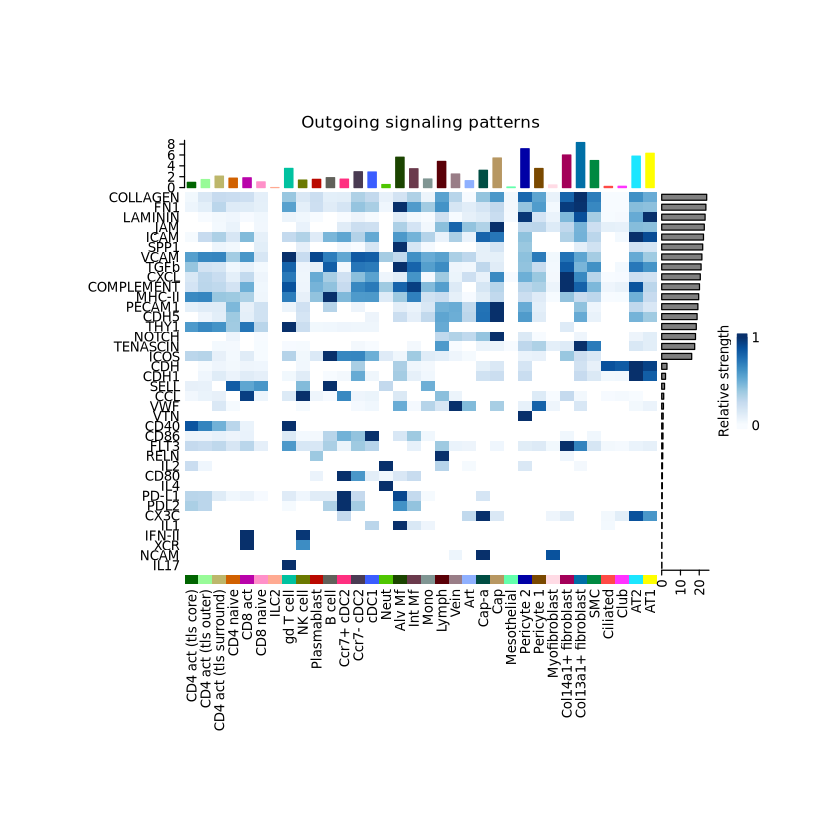

In [30]:
netAnalysis_signalingRole_heatmap(cellchat, pattern = "outgoing", color.heatmap = "Blues", color.use=celltype_palette_mapped)

### Circle plots

In [31]:
pathways.show <- c("PD-L1")

pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_circle_plot.pdf")))
p<-netVisual_aggregate(cellchat, signaling = pathways.show, 
                    targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                    layout = "circle", color.use=celltype_palette_mapped)
dev.off()


png 
  2

In [32]:
pathways.show <- c("PDL2")

pdf(file = file.path(plot_out_dir, paste0(pathways.show[1], "_circle_plot.pdf")))
p<-netVisual_aggregate(cellchat, signaling = pathways.show, 
                    targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
                    layout = "circle", color.use=celltype_palette_mapped)
dev.off()


png 
  2